# An investigation of classification methods for Diabetes 130-US Hospitals

In [1]:
!pip3 install -U ucimlrepo

In [2]:
# Fetch the data
from ucimlrepo import fetch_ucirepo

# fetch dataset
diabetes_data = fetch_ucirepo(id=296)

# data (as pandas dataframes)
X = diabetes_data.data.features.copy()
y = diabetes_data.data.targets.copy()

# metadata
print(diabetes_data.metadata)

# variable information
print(diabetes_data.variables)

/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


{'uci_id': 296, 'name': 'Diabetes 130-US Hospitals for Years 1999-2008', 'repository_url': 'https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008', 'data_url': 'https://archive.ics.uci.edu/static/public/296/data.csv', 'abstract': 'The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide pro

### Data Exploration

In [3]:
print(f"Rows: {X.shape[0]}, Columns: {X.shape[1]}")

print("\nMissing values per column:")
missing = X.isna().sum()
missing = missing[missing > 0]
print(missing)

print("\nClass distribution:")
print(y['readmitted'].value_counts())

Rows: 101766, Columns: 47

Missing values per column:
race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
max_glu_serum        96420
A1Cresult            84748
dtype: int64

Class distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


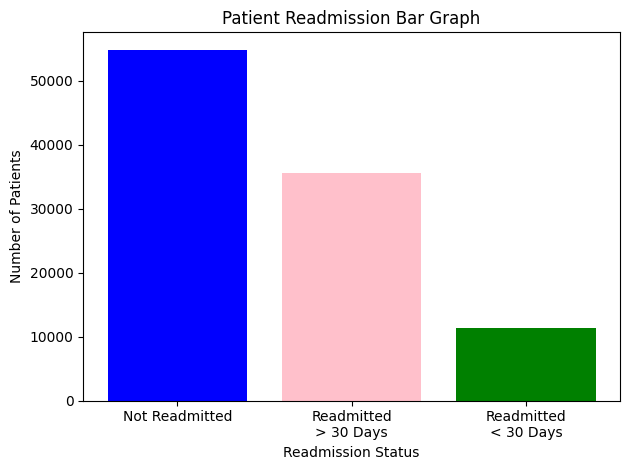

In [4]:
import matplotlib.pyplot as plt

#labels = ['Not Readmitted', 'Readmitted after more than 30 Days', 'Readmitted after less than 30 Days']
labels = ['Not Readmitted', 'Readmitted\n> 30 Days', 'Readmitted\n< 30 Days']
counts = [
    (y['readmitted'] == 'NO').sum(),
    (y['readmitted'] == '>30').sum(),
    (y['readmitted'] == '<30').sum()
]

plt.bar(labels, counts, color=['blue', 'pink', 'green'])
plt.title('Patient Readmission Bar Graph')
plt.xlabel('Readmission Status')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

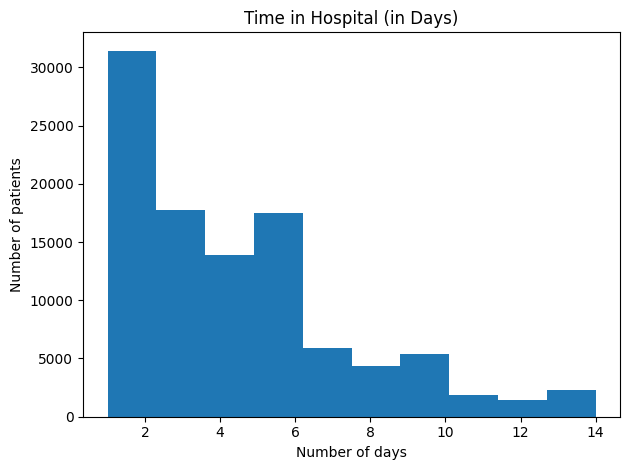

In [5]:
plt.hist(X['time_in_hospital'])
plt.title('Time in Hospital (in Days)')
plt.xlabel('Number of days')
plt.ylabel('Number of patients')
plt.tight_layout()
plt.show()

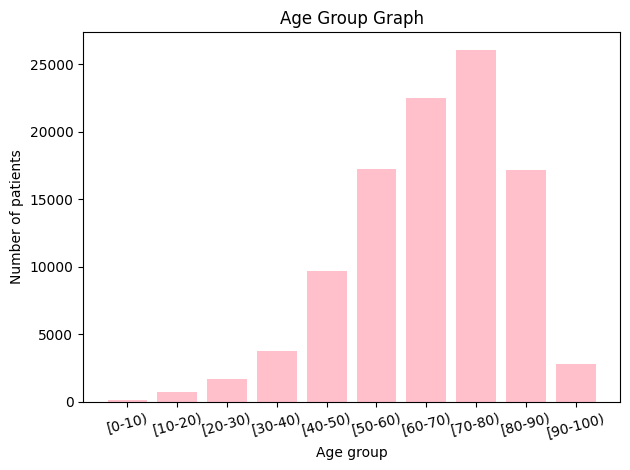

In [6]:
age_counts = X['age'].value_counts().sort_index()

plt.bar(age_counts.index, age_counts.values, color='pink')
plt.title('Age Group Graph')
plt.xlabel('Age group')
plt.ylabel('Number of patients')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

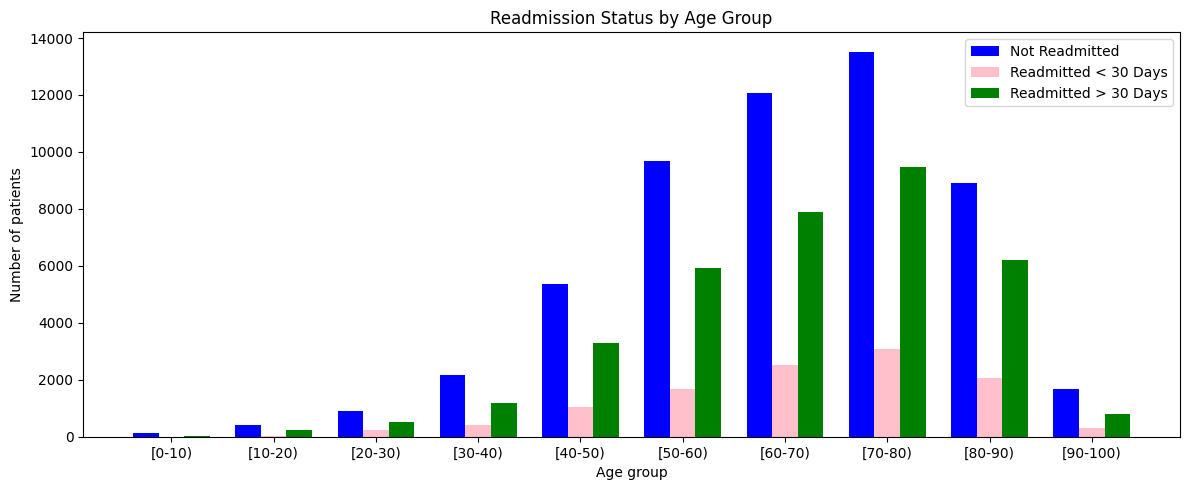

In [7]:
import numpy as np
import matplotlib.pyplot as plt

x_copy = X.copy()
x_copy['readmitted'] = y['readmitted'].values

no_readmit = x_copy[x_copy['readmitted'] == 'NO']
less_than_30_readmit = x_copy[x_copy['readmitted'] == '<30']
greater_than_30_readmit = x_copy[x_copy['readmitted'] == '>30']

age_order = sorted(x_copy['age'].unique())

no_patients = []
less_than_30_patients = []
greater_than_30_patients = []

for i in age_order:
    no_patients.append(len(no_readmit[no_readmit['age'] == i]))
    less_than_30_patients.append(len(less_than_30_readmit[less_than_30_readmit['age'] == i]))
    greater_than_30_patients.append(len(greater_than_30_readmit[greater_than_30_readmit['age'] == i]))

w, x = 0.25, np.arange(len(age_order))
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w, no_patients, width=w, label='Not Readmitted', color='blue')
ax.bar(x, less_than_30_patients, width=w, label='Readmitted < 30 Days', color='pink')
ax.bar(x + w, greater_than_30_patients, width=w, label='Readmitted > 30 Days', color='green')
ax.set_xticks(x)
ax.set_xticklabels(age_order)
ax.set_ylabel('Number of patients')
ax.set_xlabel('Age group')
ax.set_title('Readmission Status by Age Group')
ax.legend()
plt.tight_layout()
plt.show()

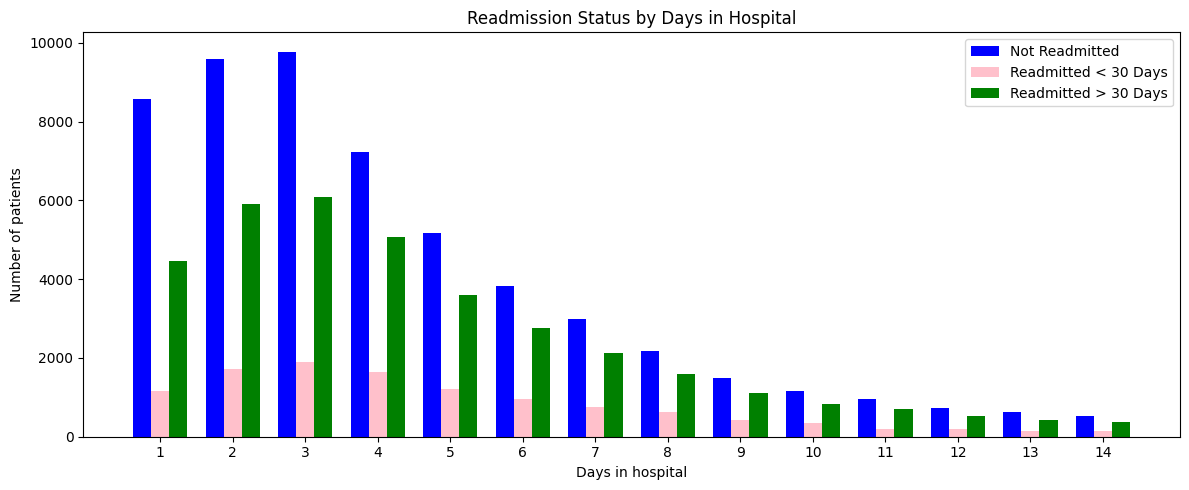

In [8]:
days = list(range(1, 15))

no_days = []
less_than_30_days = []
greater_than_30_days = []

for i in days:
    no_days.append(len(no_readmit[no_readmit['time_in_hospital'] == i]))
    less_than_30_days.append(len(less_than_30_readmit[less_than_30_readmit['time_in_hospital'] == i]))
    greater_than_30_days.append(len(greater_than_30_readmit[greater_than_30_readmit['time_in_hospital'] == i]))

w, x = 0.25, np.arange(len(days))
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w, no_days, width=w, label='Not Readmitted', color='blue')
ax.bar(x,less_than_30_days, width=w, label='Readmitted < 30 Days', color='pink')
ax.bar(x + w, greater_than_30_days, width=w, label='Readmitted > 30 Days', color='green')
ax.set_xticks(x)
ax.set_xticklabels(days)
ax.set_xlabel('Days in hospital')
ax.set_ylabel('Number of patients')
ax.set_title('Readmission Status by Days in Hospital')
ax.legend()
plt.tight_layout()
plt.show()

### Feedforward Neural Networks

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
import matplotlib.pyplot as plt

y_binary = y['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

def run_experiment(X_data, y_data, split_ratio, handling_method):
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X_data, y_data, test_size=0.20, random_state=42, stratify=y_data
    )

    val_size = (1 - split_ratio) / 0.8
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=val_size, random_state=42, stratify=y_train_val
    )

    num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
    cat_cols = X_train.select_dtypes(include=['object']).columns

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

    X_train_proc = preprocessor.fit_transform(X_train)
    X_val_proc = preprocessor.transform(X_val)
    X_test_proc = preprocessor.transform(X_test)

    mlp = MLPClassifier(
        hidden_layer_sizes=(128, 128),
        activation='relu',
        solver='adam',
        alpha=0.01,
        batch_size=256,
        learning_rate_init=0.001,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=42,
        max_iter=800
    )
    mlp.fit(X_train_proc, y_train)

    y_pred = mlp.predict(X_test_proc)
    # y_probs = mlp.predict_proba(X_test_proc)[:, 1]
    # y_pred = (y_probs > 0.40).astype(int)

    results = {
        "Method": handling_method,
        "Split": f"{int(split_ratio*100)}/{(100-int(split_ratio*100))}",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred)
    }
    return results

def print_results(results_df):
    print("Results: \n")
    print(results_df)

    results_df.set_index(['Method', 'Split'])[['Accuracy', 'Recall']].plot(kind='bar', figsize=(10,6))
    plt.title("Comparison of Missing Value Handling and Data Splits")
    plt.ylabel("Score")
    plt.xticks(rotation=45)
    plt.show()

Running experiment with split 80/20 and replace with mean:
Running experiment with split 70/30 and replace with mean:
Dropping columns with too many missing values: ['weight', 'medical_specialty', 'max_glu_serum', 'A1Cresult']
Original samples: 101766, Samples remaining after row removal: 59129
Running experiment with split 80/20 and removal method:
Running experiment with split 70/30 and removal method:
Results: 

                           Method  Split  Accuracy  Precision    Recall
0  Replace missing data with Mean  80/20  0.888523   0.516667  0.013650
1  Replace missing data with Mean  70/30  0.888179   0.480315  0.026860
2             Remove Missing Rows  80/20  0.888720   0.361702  0.013047
3             Remove Missing Rows  70/30  0.889481   0.333333  0.003070


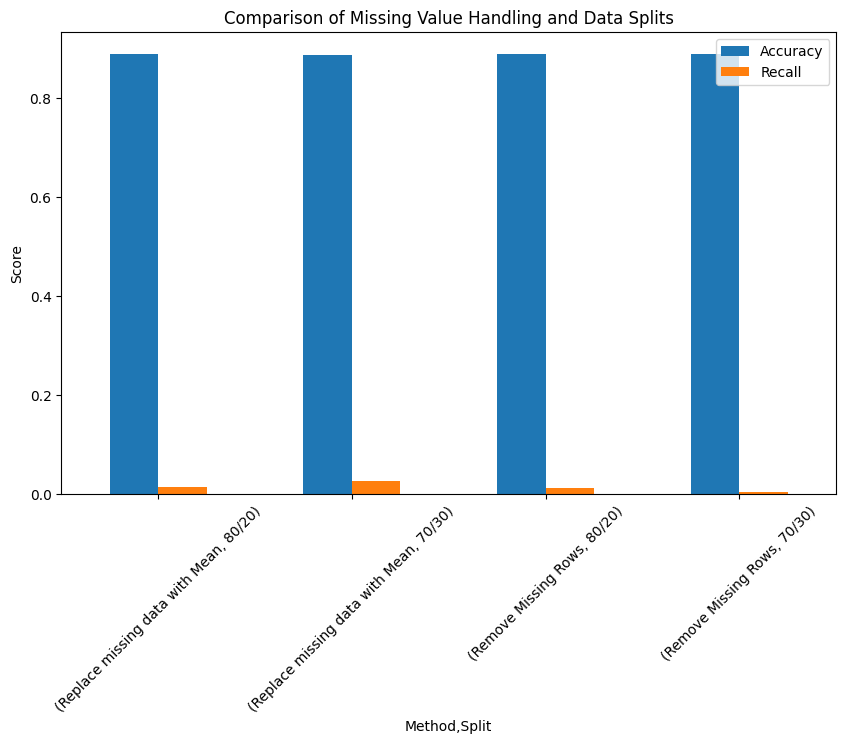

In [10]:
all_results = []
splits = [0.8, 0.7]

X_imputed = X.replace('?', np.nan)
for col in X_imputed.columns:
    if X_imputed[col].dtype == 'object':
        X_imputed[col] = X_imputed[col].fillna(X_imputed[col].mode()[0])
    else:
        X_imputed[col] = X_imputed[col].fillna(X_imputed[col].mean())

for s in splits:
    print(f"Running experiment with split {int(s*100)}/{(100-int(s*100))} and replace with mean:")
    all_results.append(run_experiment(X_imputed, y_binary, s, "Replace missing data with Mean"))

X_temp = X.replace('?', np.nan)
cols_to_drop = X_temp.columns[X_temp.isnull().mean() > 0.40]
print(f"Dropping columns with too many missing values: {list(cols_to_drop)}")

X_dropped = X_temp.drop(columns=cols_to_drop).dropna()
y_dropped = y_binary.loc[X_dropped.index]

print(f"Original samples: {len(X)}, Samples remaining after row removal: {len(X_dropped)}")

for s in splits:
    print(f"Running experiment with split {int(s*100)}/{(100-int(s*100))} and removal method:")
    all_results.append(run_experiment(X_dropped, y_dropped, s, "Remove Missing Rows"))

results_df = pd.DataFrame(all_results)
print_results(results_df)

Running experiment with split 80/20 and replace with mean:
Running experiment with split 70/30 and replace with mean:
Dropping columns with too many missing values: ['weight', 'medical_specialty', 'max_glu_serum', 'A1Cresult']
Original samples: 101766, Samples remaining after row removal: 59129
Running experiment with split 80/20 and removal method:
Running experiment with split 70/30 and removal method:
Results: 

                           Method  Split  Accuracy  Precision    Recall
0  Replace missing data with Mean  80/20  0.638056   0.652576  0.459119
1  Replace missing data with Mean  70/30  0.634765   0.604173  0.601855
2             Remove Missing Rows  80/20  0.637832   0.617952  0.592158
3             Remove Missing Rows  70/30  0.635633   0.609865  0.614384


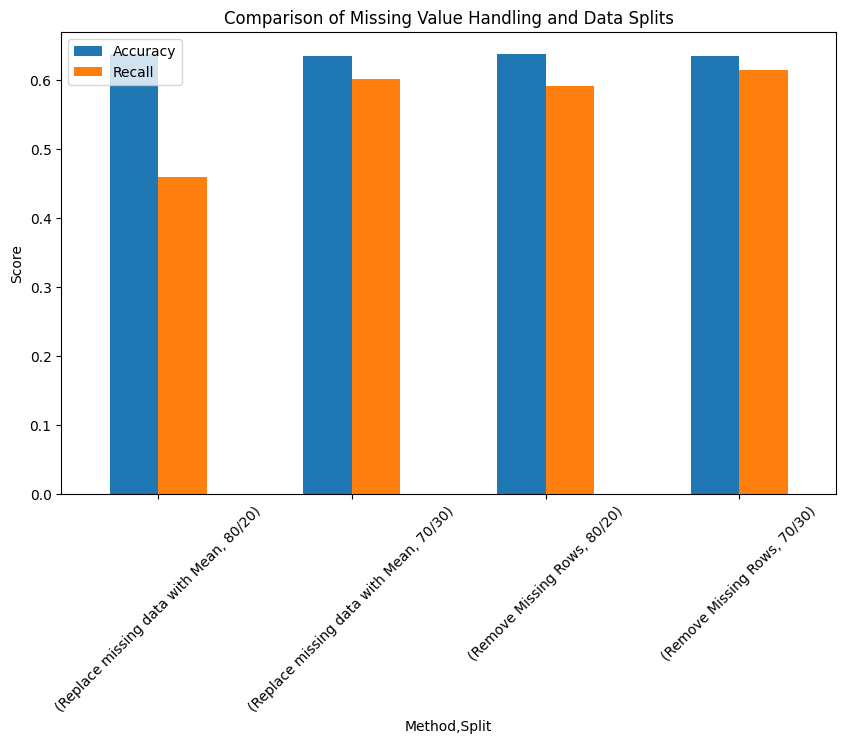

In [11]:
y_binary = y['readmitted'].apply(lambda x: 1 if x != 'NO' else 0)

all_results = []
splits = [0.8, 0.7]

X_imputed = X.replace('?', np.nan)
for col in X_imputed.columns:
    if X_imputed[col].dtype == 'object':
        X_imputed[col] = X_imputed[col].fillna(X_imputed[col].mode()[0])
    else:
        X_imputed[col] = X_imputed[col].fillna(X_imputed[col].mean())

for s in splits:
    print(f"Running experiment with split {int(s*100)}/{(100-int(s*100))} and replace with mean:")
    all_results.append(run_experiment(X_imputed, y_binary, s, "Replace missing data with Mean"))

X_temp = X.replace('?', np.nan)
cols_to_drop = X_temp.columns[X_temp.isnull().mean() > 0.40]
print(f"Dropping columns with too many missing values: {list(cols_to_drop)}")

X_dropped = X_temp.drop(columns=cols_to_drop).dropna()
y_dropped = y_binary.loc[X_dropped.index]

print(f"Original samples: {len(X)}, Samples remaining after row removal: {len(X_dropped)}")

for s in splits:
    print(f"Running experiment with split {int(s*100)}/{(100-int(s*100))} and removal method:")
    all_results.append(run_experiment(X_dropped, y_dropped, s, "Remove Missing Rows"))

results_df = pd.DataFrame(all_results)
print_results(results_df)

### KNN



In [12]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

X_clean = X.copy()
for col in X_clean.columns:
    if X_clean[col].dtype == 'object':
        X_clean[col] = X_clean[col].fillna(X_clean[col].mode()[0])
    else:
        X_clean[col] = X_clean[col].fillna(X_clean[col].mean())

for col in X_clean.select_dtypes(include='object').columns:
    X_clean[col] = LabelEncoder().fit_transform(X_clean[col].astype(str))

y_enc = y['readmitted'].apply(lambda x: 1 if x != 'NO' else 0).values

seed = 1234
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_enc, test_size=0.20, random_state=seed)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=seed)

print(f"Train: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Train: 61059, Validation: 20353, Test: 20354


In [13]:
k_values = [1, 10, 50, 100, 500, 1000]
val_errors = []
train_errors = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, knn.predict(X_train))
    val_acc = accuracy_score(y_val, knn.predict(X_val))

    train_errors.append(1 - train_acc)
    val_errors.append(1 - val_acc)

    print(f"k={k}, train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

k=1, train_acc=1.0000, val_acc=0.5496
k=10, train_acc=0.6717, val_acc=0.5869
k=50, train_acc=0.6293, val_acc=0.5958
k=100, train_acc=0.6218, val_acc=0.6020
k=500, train_acc=0.6100, val_acc=0.6053
k=1000, train_acc=0.6074, val_acc=0.6028


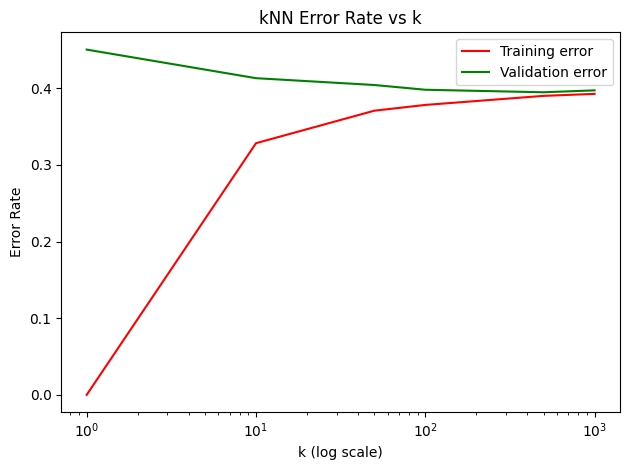

In [14]:
import matplotlib.pyplot as plt

plt.semilogx(k_values, train_errors, color='red', label='Training error')
plt.semilogx(k_values, val_errors, color='green', label='Validation error')
plt.xlabel('k (log scale)')
plt.ylabel('Error Rate')
plt.title('kNN Error Rate vs k')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
best_k = k_values[np.argmin(val_errors)]
print(f"Best k = {best_k}")

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)
y_pred = knn_final.predict(X_test)
from sklearn.metrics import precision_score, recall_score
print("Test Accuracy: ", accuracy_score(y_test, y_pred))
print("Test Precision: ", precision_score(y_test, y_pred))
print("Test Recall: ", recall_score(y_test, y_pred))

Best k = 500
Test Accuracy:  0.6067112115554683
Test Precision:  0.6272349647823732
Test Recall:  0.36891863182494156


### Decision Trees

In [17]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [18]:
# (same missing-value handling as KNN)
X_clean = X.copy()
for col in X_clean.columns:
    if X_clean[col].dtype == 'object':
        X_clean[col] = X_clean[col].fillna(X_clean[col].mode()[0])
    else:
        X_clean[col] = X_clean[col].fillna(X_clean[col].mean())

In [19]:
# Replace '?' with NaN then impute (as referenced from FAQ)
X_clean = X_clean.replace('?', np.nan)
for col in X_clean.columns:
    if X_clean[col].dtype == 'object':
        X_clean[col] = X_clean[col].fillna(X_clean[col].mode()[0])
    else:
        X_clean[col] = X_clean[col].fillna(X_clean[col].mean())

In [20]:
# Label encode categorical features
label_encoders = {}
for col in X_clean.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_clean[col] = le.fit_transform(X_clean[col].astype(str))
    label_encoders[col] = le

In [21]:
# 3-class target: NO=0, <30=1, >30=2
y_enc = LabelEncoder().fit_transform(y.values.ravel())
target_names = ['<30 days', 'NOT readmitted', '>30 days']

In [22]:
# 60% train, 20% validation, 20% test (same as KNN section)
seed = 1234
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_enc, test_size=0.20, random_state=seed
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=seed
)

print(f"Train: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")

Train: 61059, Validation: 20353, Test: 20354


In [23]:
# Hyperparameter Tuning: max_depth
depth_values = [2, 3, 5, 7, 10, 15, 20, 30, None]
train_errors = []
val_errors = []

for d in depth_values:
    dt = DecisionTreeClassifier(max_depth=d, random_state=seed)
    dt.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, dt.predict(X_train))
    val_acc = accuracy_score(y_val, dt.predict(X_val))

    train_errors.append(1 - train_acc)
    val_errors.append(1 - val_acc)

    label = str(d) if d is not None else "None"
    print(f"max_depth={label:>4s}, train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

max_depth=   2, train_acc=0.5646, val_acc=0.5663
max_depth=   3, train_acc=0.5681, val_acc=0.5700
max_depth=   5, train_acc=0.5760, val_acc=0.5747
max_depth=   7, train_acc=0.5837, val_acc=0.5762
max_depth=  10, train_acc=0.6054, val_acc=0.5704
max_depth=  15, train_acc=0.6888, val_acc=0.5450
max_depth=  20, train_acc=0.8096, val_acc=0.5120
max_depth=  30, train_acc=0.9760, val_acc=0.4767
max_depth=None, train_acc=1.0000, val_acc=0.4728


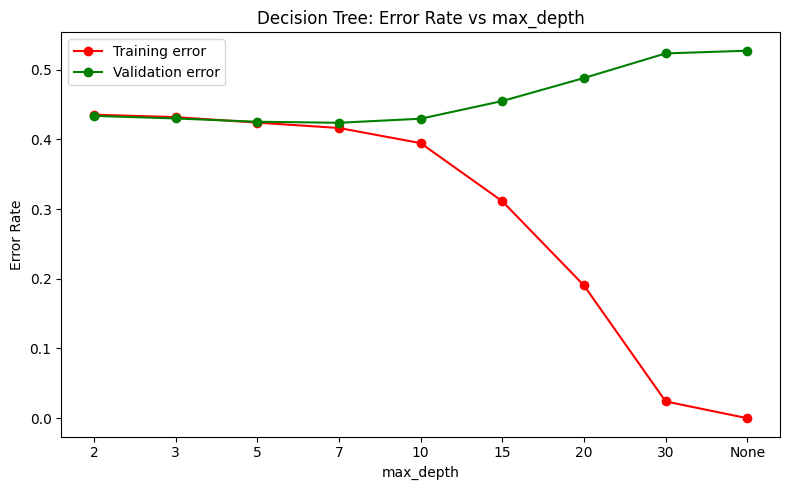

In [24]:
# Plot depth vs error
depth_labels = [str(d) if d is not None else "None" for d in depth_values]
x_pos = np.arange(len(depth_values))

plt.figure(figsize=(8, 5))
plt.plot(x_pos, train_errors, 'o-', color='red', label='Training error')
plt.plot(x_pos, val_errors, 'o-', color='green', label='Validation error')
plt.xticks(x_pos, depth_labels)
plt.xlabel('max_depth')
plt.ylabel('Error Rate')
plt.title('Decision Tree: Error Rate vs max_depth')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# Hyperparameter Tuning: min_samples_leaf
best_depth_idx = np.argmin(val_errors)
best_depth = depth_values[best_depth_idx]
print(f"\nBest max_depth from sweep: {best_depth}")

leaf_values = [1, 5, 10, 25, 50, 100, 250, 500]
train_errors_leaf = []
val_errors_leaf = []

for ml in leaf_values:
    dt = DecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=ml, random_state=seed)
    dt.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, dt.predict(X_train))
    val_acc = accuracy_score(y_val, dt.predict(X_val))

    train_errors_leaf.append(1 - train_acc)
    val_errors_leaf.append(1 - val_acc)

    print(f"min_samples_leaf={ml:>4d}, train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")


Best max_depth from sweep: 7
min_samples_leaf=   1, train_acc=0.5837, val_acc=0.5762
min_samples_leaf=   5, train_acc=0.5833, val_acc=0.5760
min_samples_leaf=  10, train_acc=0.5830, val_acc=0.5769
min_samples_leaf=  25, train_acc=0.5829, val_acc=0.5770
min_samples_leaf=  50, train_acc=0.5825, val_acc=0.5766
min_samples_leaf= 100, train_acc=0.5815, val_acc=0.5753
min_samples_leaf= 250, train_acc=0.5798, val_acc=0.5765
min_samples_leaf= 500, train_acc=0.5780, val_acc=0.5776


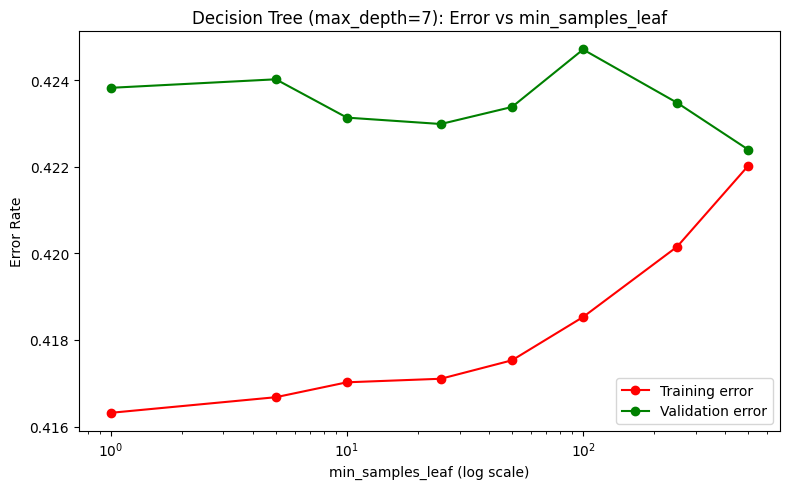

Best min_samples_leaf: 500


In [26]:
plt.figure(figsize=(8, 5))
plt.semilogx(leaf_values, train_errors_leaf, 'o-', color='red', label='Training error')
plt.semilogx(leaf_values, val_errors_leaf, 'o-', color='green', label='Validation error')
plt.xlabel('min_samples_leaf (log scale)')
plt.ylabel('Error Rate')
plt.title(f'Decision Tree (max_depth={best_depth}): Error vs min_samples_leaf')
plt.legend()
plt.tight_layout()
plt.show()

best_leaf_idx = np.argmin(val_errors_leaf)
best_leaf = leaf_values[best_leaf_idx]
print(f"Best min_samples_leaf: {best_leaf}")

In [27]:
# Final Model: Train + Evaluate on Test Set
dt_final = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_leaf=best_leaf,
    criterion='gini',
    random_state=seed
)
dt_final.fit(X_train, y_train)

y_pred = dt_final.predict(X_test)

In [28]:
print(f"\n--- Final Decision Tree (max_depth={best_depth}, min_samples_leaf={best_leaf}) ---")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))


--- Final Decision Tree (max_depth=7, min_samples_leaf=500) ---
Test Accuracy: 0.5789

Classification Report:
                precision    recall  f1-score   support

      <30 days       0.00      0.00      0.00      2308
NOT readmitted       0.49      0.37      0.42      7106
      >30 days       0.61      0.84      0.71     10940

      accuracy                           0.58     20354
     macro avg       0.37      0.40      0.38     20354
  weighted avg       0.50      0.58      0.53     20354



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


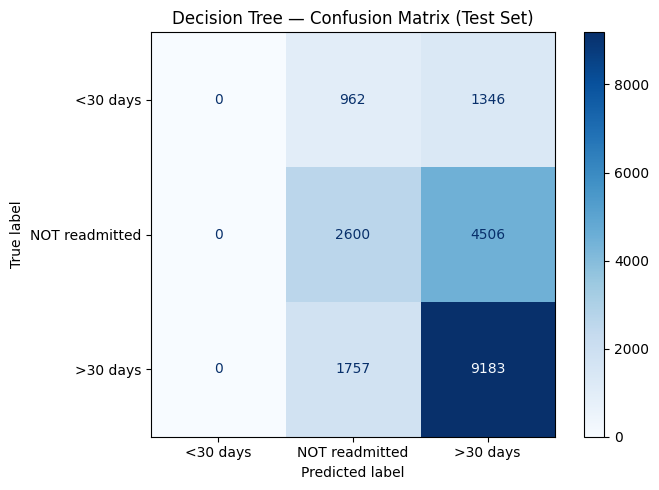

In [29]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap='Blues')
plt.title('Decision Tree — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

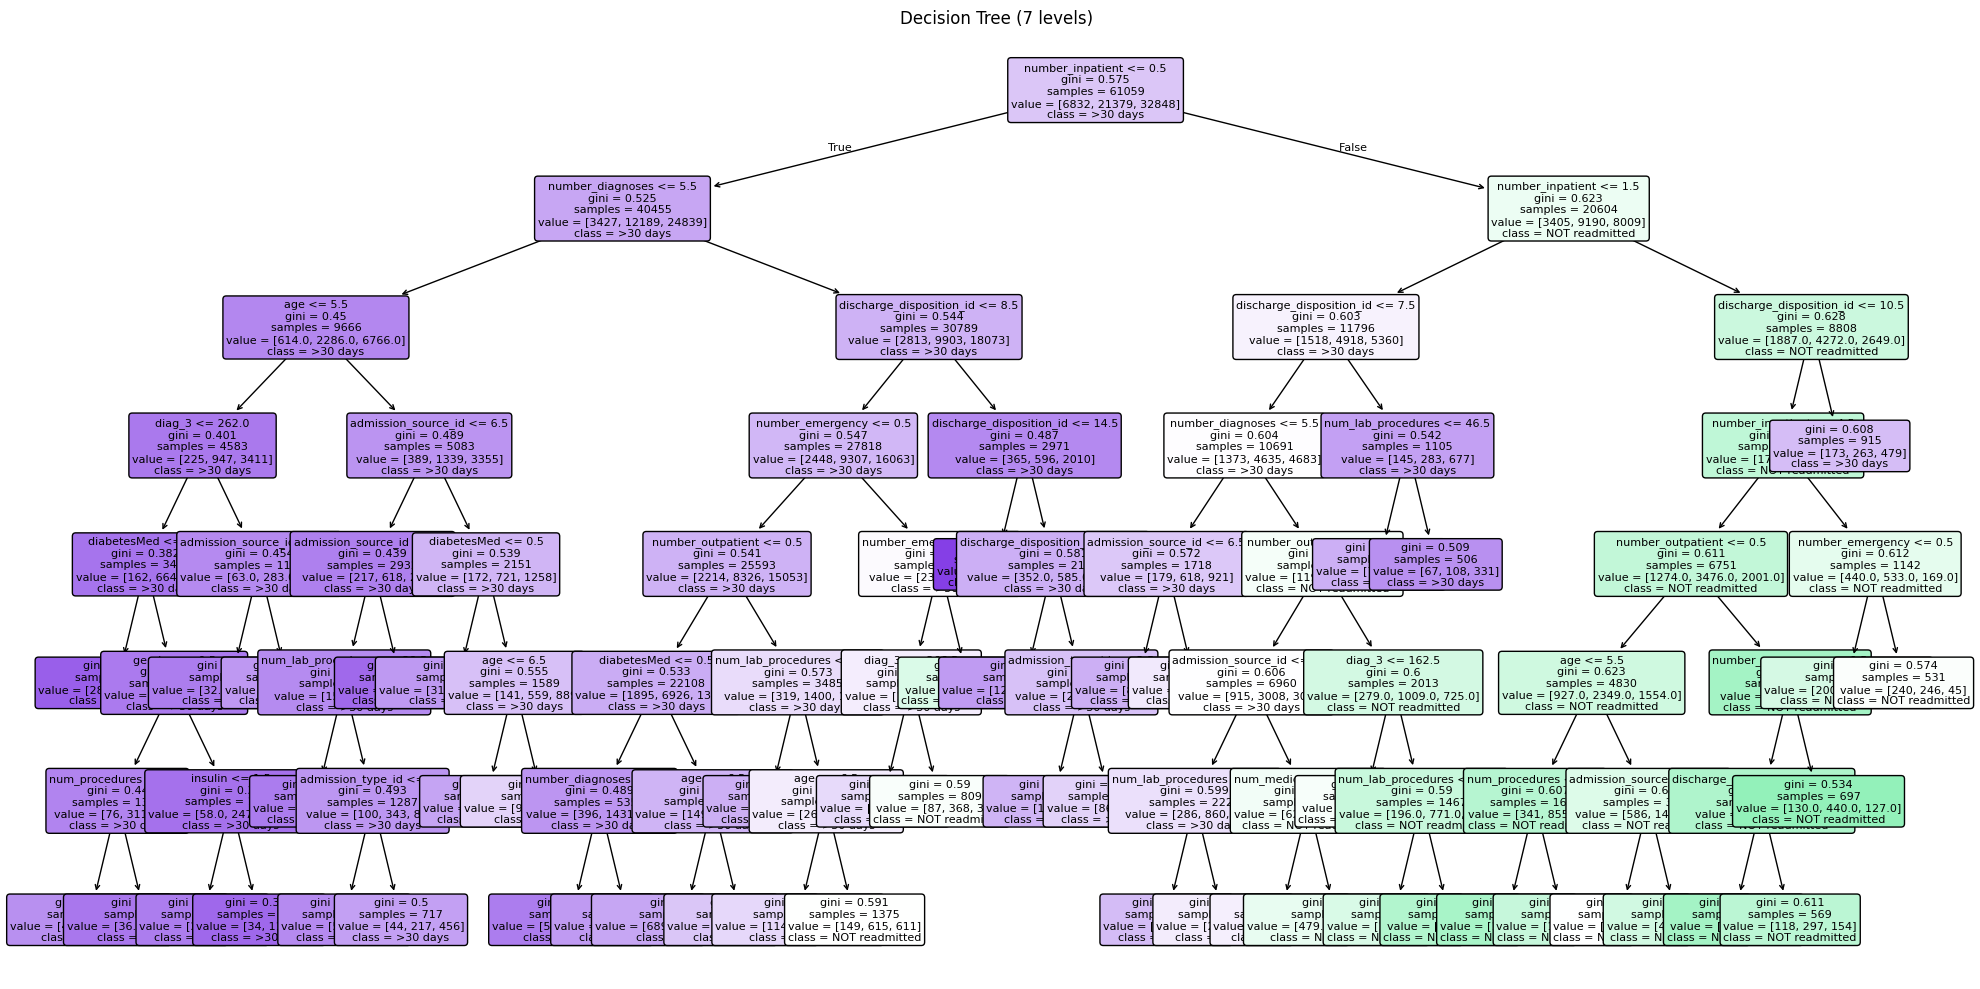

In [35]:
# Tree Visualization (depth-limited for readability)
plt.figure(figsize=(20, 10))
plot_tree(
    dt_final,
    max_depth=7,  # only show top 3 levels so the plot is readable
    filled=True,
    feature_names=X_clean.columns.tolist(),
    class_names=target_names,
    rounded=True,
    fontsize=8
)
plt.title('Decision Tree (7 levels)')
plt.tight_layout()
plt.show()

In [36]:
# Train vs Test Accuracy Summary
train_acc_final = accuracy_score(y_train, dt_final.predict(X_train))
test_acc_final = accuracy_score(y_test, y_pred)
print(f"\nTrain Accuracy: {train_acc_final:.4f}")
print(f"Test Accuracy:  {test_acc_final:.4f}")
print(f"Gap:            {train_acc_final - test_acc_final:.4f}")


Train Accuracy: 0.5780
Test Accuracy:  0.5789
Gap:            -0.0009


In [37]:
### Logistic Classifier

In [38]:
# fetch dataset
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296)
# data (as pandas dataframes)
X = diabetes_130_us_hospitals_for_years_1999_2008.data.features
y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets
# metadata
print(diabetes_130_us_hospitals_for_years_1999_2008.metadata)
# variable information
print(diabetes_130_us_hospitals_for_years_1999_2008.variables)

/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


{'uci_id': 296, 'name': 'Diabetes 130-US Hospitals for Years 1999-2008', 'repository_url': 'https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008', 'data_url': 'https://archive.ics.uci.edu/static/public/296/data.csv', 'abstract': 'The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide pro

In [39]:
SEED = 42
np.random.seed(SEED)

df = pd.concat([X, y], axis=1)
df = df.replace("?", np.nan)
print(f"Shape: {df.shape}")
df.head()

Shape: (101766, 48)


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [40]:
print(df["readmitted"].value_counts())
print()
print(df["readmitted"].value_counts(normalize=True))

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: proportion, dtype: float64


In [41]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64


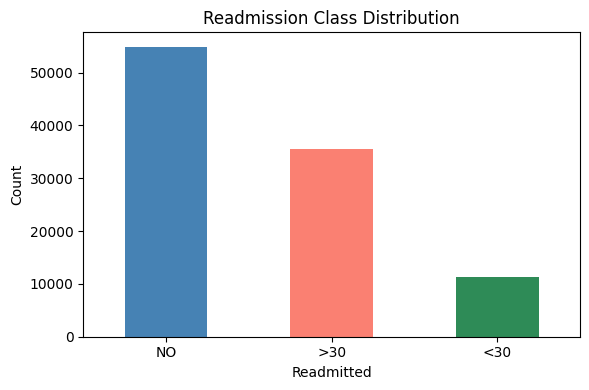

In [42]:
fig, ax = plt.subplots(figsize=(6, 4))
df["readmitted"].value_counts().plot(kind="bar", ax=ax, color=["steelblue", "salmon", "seagreen"])
ax.set_title("Readmission Class Distribution")
ax.set_xlabel("Readmitted")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [43]:
for col in ["encounter_id", "patient_nbr"]:
    if col in df.columns:
        df = df.drop(columns=[col])

high_missing = [col for col in df.columns if df[col].isnull().mean() > 0.40]
print(f"Dropping high-missing columns: {high_missing}")
df = df.drop(columns=high_missing)

X = df.drop(columns=["readmitted"])
y = df["readmitted"]

Dropping high-missing columns: ['weight', 'medical_specialty', 'max_glu_serum', 'A1Cresult']


In [44]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=SEED, stratify=y_train_val
)

print(f"Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}")

numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print(f"Numeric features ({len(numeric_cols)}):  {numeric_cols[:5]} ...")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols[:5]} ...")

Train: 61059  Val: 20353  Test: 20354
Numeric features (11):  ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures'] ...
Categorical features (32): ['race', 'gender', 'age', 'payer_code', 'diag_1'] ...


In [45]:
train_means = X_train[numeric_cols].mean()
X_train[numeric_cols] = X_train[numeric_cols].fillna(train_means)
X_val[numeric_cols]   = X_val[numeric_cols].fillna(train_means)
X_test[numeric_cols]  = X_test[numeric_cols].fillna(train_means)

train_modes = X_train[categorical_cols].mode().iloc[0]
X_train[categorical_cols] = X_train[categorical_cols].fillna(train_modes)
X_val[categorical_cols]   = X_val[categorical_cols].fillna(train_modes)
X_test[categorical_cols]  = X_test[categorical_cols].fillna(train_modes)

In [46]:
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    le.fit(X_train[col])
    X_train[col] = le.transform(X_train[col])
    X_val[col]  = X_val[col].map(lambda v, _le=le: v if v in _le.classes_ else _le.classes_[0])
    X_test[col] = X_test[col].map(lambda v, _le=le: v if v in _le.classes_ else _le.classes_[0])
    X_val[col]  = le.transform(X_val[col])
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le

print("Label encoding complete.")
print(f"Remaining missing values — train: {X_train.isnull().sum().sum()}, "
      f"val: {X_val.isnull().sum().sum()}, test: {X_test.isnull().sum().sum()}")


Label encoding complete.
Remaining missing values — train: 0, val: 0, test: 0


In [47]:
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols]   = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])

print("Standardization complete.")
X_train.head()

Standardization complete.


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,num_lab_procedures,num_procedures,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
76291,2,1,8,-0.707849,0.435996,0.311105,-0.469946,7,-1.639515,0.390360,...,0,0,1,1,0,0,0,0,0,1
24452,2,1,7,-0.707849,-0.134139,0.311105,1.540265,7,0.397996,-0.786066,...,0,0,3,1,0,0,0,0,0,1
54430,2,0,7,-0.707849,-0.514228,-1.172126,-1.140016,7,-1.741390,-0.786066,...,0,0,2,1,0,0,0,0,0,1
85512,0,1,5,0.682393,-0.514228,-1.172126,-0.804981,7,-1.435764,-0.786066,...,0,0,2,1,0,0,0,0,1,1
84580,2,0,5,0.682393,-0.514228,-1.172126,-0.469946,12,-0.773573,2.743213,...,0,0,3,1,0,0,0,0,0,1


In [49]:
from sklearn.linear_model import LogisticRegression

C_values = [0.001, 0.01, 0.1, 1, 10, 100]
penalties = ["l1", "l2"]

results = []

for pen in penalties:
    for c in C_values:
        model = LogisticRegression(
            C=c, penalty=pen, solver="saga",
            max_iter=5000, random_state=SEED, n_jobs=-1
        )
        model.fit(X_train, y_train)

        train_acc = accuracy_score(y_train, model.predict(X_train))
        val_acc   = accuracy_score(y_val,   model.predict(X_val))

        results.append({
            "penalty": pen, "C": c,
            "train_acc": train_acc, "val_acc": val_acc
        })
        print(f"penalty={pen:>2s}  C={c:<7.3f}  "
              f"train_acc={train_acc:.4f}  val_acc={val_acc:.4f}")

results_df = pd.DataFrame(results)
print("\n--- Best by validation accuracy ---")
print(results_df.loc[results_df["val_acc"].idxmax()])

penalty=l1  C=0.001    train_acc=0.5650  val_acc=0.5658
penalty=l1  C=0.010    train_acc=0.5711  val_acc=0.5701
penalty=l1  C=0.100    train_acc=0.5710  val_acc=0.5708
penalty=l1  C=1.000    train_acc=0.5710  val_acc=0.5705
penalty=l1  C=10.000   train_acc=0.5711  val_acc=0.5705
penalty=l1  C=100.000  train_acc=0.5711  val_acc=0.5705
penalty=l2  C=0.001    train_acc=0.5708  val_acc=0.5699
penalty=l2  C=0.010    train_acc=0.5710  val_acc=0.5707
penalty=l2  C=0.100    train_acc=0.5710  val_acc=0.5704
penalty=l2  C=1.000    train_acc=0.5711  val_acc=0.5705
penalty=l2  C=10.000   train_acc=0.5711  val_acc=0.5705
penalty=l2  C=100.000  train_acc=0.5711  val_acc=0.5705

--- Best by validation accuracy ---
penalty            l1
C                 0.1
train_acc    0.571021
val_acc      0.570825
Name: 2, dtype: object


NameError: name 'penalties' is not defined

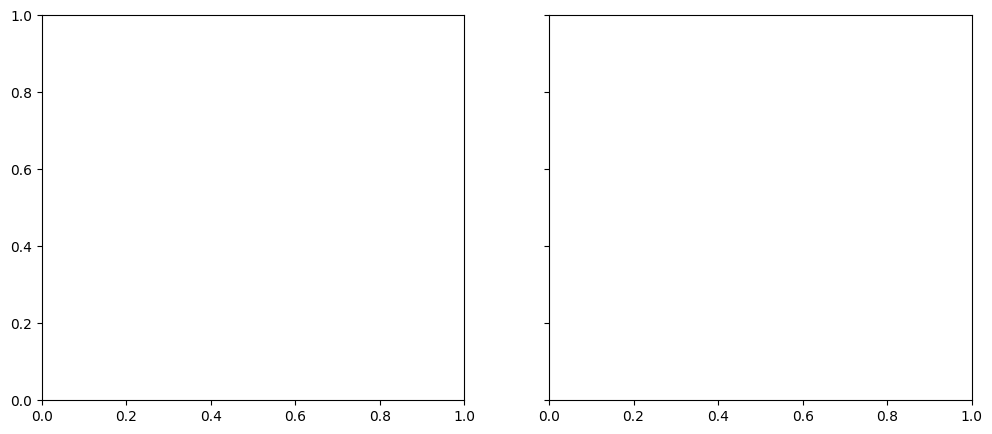

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, pen in enumerate(penalties):
    subset = results_df[results_df["penalty"] == pen]
    axes[i].plot(subset["C"], subset["train_acc"], "o-", label="Train")
    axes[i].plot(subset["C"], subset["val_acc"],   "s-", label="Validation")
    axes[i].set_xscale("log")
    axes[i].set_xlabel("C (inverse regularization strength)")
    axes[i].set_ylabel("Accuracy")
    axes[i].set_title(f"Logistic Regression — {pen.upper()} penalty")
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
best_row = results_df.loc[results_df["val_acc"].idxmax()]
best_C   = best_row["C"]
best_pen = best_row["penalty"]
print(f"Best hyperparameters:  penalty={best_pen}, C={best_C}")

X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

final_model = LogisticRegression(
    C=best_C, penalty=best_pen, solver="saga",
    max_iter=5000, random_state=SEED, n_jobs=-1
)
final_model.fit(X_train_full, y_train_full)

y_pred = final_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {test_acc:.4f}")

In [ ]:
print(classification_report(y_test, y_pred))

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=final_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_model.classes_)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues")
ax.set_title("Logistic Regression — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes_frac = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]

train_sizes_abs, train_scores, val_scores = learning_curve(
    LogisticRegression(C=best_C, penalty=best_pen, solver="saga",
                       max_iter=5000, random_state=SEED, n_jobs=-1),
    X_train_full, y_train_full,
    train_sizes=train_sizes_frac,
    cv=3, scoring="accuracy", n_jobs=-1
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes_abs, train_scores.mean(axis=1), "o-", label="Train")
ax.plot(train_sizes_abs, val_scores.mean(axis=1),   "s-", label="CV Validation")
ax.set_xlabel("Training Set Size")
ax.set_ylabel("Accuracy")
ax.set_title("Logistic Regression — Learning Curve")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()